In [1]:
import matplotlib.pyplot as plt
import numpy as np
import scipy as sp
import pandas as pd
import os
import gc
import sys

sys.path.insert(0, '..')
from src import *

In [2]:
path = Filepaths.DATA.value / 'convergence' / 'gpu_dt0.005'
data = Data(path)
dataset = data.read(['thermo', 'press', 'press_pot', 'born', 'born_nl'], dropdup=['timestep'])
thermo_data, press_data, press_pot_data, born_data, born_nl_data = dataset.values()
scale = data.get_scale()

/home/fgarbuzov/Documents/lammps_test/notebooks/../src/read_write.py:95: UserWarning: No scale was found in the logs, returning 1
  warnings.warn("No scale was found in the logs, returning 1")


In [3]:
# debug
# min_len = np.min([len(thermo_data), len(press_data), len(born_data), len(press_pot_data)])
# thermo_data = thermo_data[:min_len]
# press_data = press_data[:min_len]
# press_pot_data = press_pot_data[:min_len]
# born_data = born_data[:min_len]

dt = thermo_data.time[1] - thermo_data.time[0]
time = thermo_data.time

In [1]:
data2 = Data(Filepaths.DATA.value / 'convergence' / 'gpu_dt0.001')
thermo_data2 = data2.read(['thermo'])['thermo']

plt.figure(figsize=(4,3))
plt.plot(thermo_data.time, sp.ndimage.gaussian_filter(
    thermo_data.energy/thermo_data.energy[0], 100))
mask = thermo_data2.time>0
plt.plot(thermo_data2.time[mask], sp.ndimage.gaussian_filter(
    thermo_data2.energy[mask]/thermo_data2.energy[0], 100))

NameError: name 'Data' is not defined

In [7]:
trim = len(press_data)

# create 2nd and 4th order tensors out of pressure (stress) and born data
press_raw = np.array(press_data.iloc[:trim,2:]) * scale
stress = -lammps_array_to_matrix(press_raw)
stress_d = stress - stress.mean(axis=0)
press_avg = -np.trace(stress.mean(axis=0)) / 3
# N = stress_d.shape[0]

born_len = min(1_000_000, trim)
press_pot_raw = np.array(press_pot_data.iloc[:born_len,2:]) * scale
press_kin_raw = press_raw[:born_len] - press_pot_raw
stress_kin = -lammps_array_to_matrix(press_kin_raw)
stress_kin_mean = stress_kin.mean(axis=0)

born_raw = np.array(born_data.iloc[:born_len,2:]) * scale / thermo_data.vol[0]
born_voigt = lammps_array_to_matrix(born_raw)
CB = voigt_to_tensor(born_voigt)
CB_avg = CB.mean(axis=0)
CK = -4 * sym_dyad(np.eye(3), stress_kin)
CBK = CB + CK
CBK_avg = CBK.mean(axis=0)

born_nl_raw = np.array(born_nl_data.iloc[:,2:]) * scale / thermo_data.vol[0]
born_nl_voigt = lammps_array_to_matrix(born_nl_raw.reshape(len(born_nl_raw), 21, 6).swapaxes(-1, -2))
NB_avg = voigt_to_tensor(born_nl_voigt, order=3).mean(axis=0)
NK_avg = -sym_dyad(np.eye(3), CBK_avg) / 8
NK_avg += NK_avg.swapaxes(0, 2).swapaxes(1,3) + NK_avg.swapaxes(0, 4).swapaxes(1,5)
NBK_avg = NB_avg + NK_avg

In [18]:
def major_symmetry6(tens):
    tens_t = np.swapaxes(np.swapaxes(tens, -6, -4), -5, -3)
    print('ij<->kl:', np.linalg.norm(tens - tens_t))
    tens_t = np.swapaxes(np.swapaxes(tens, -3, -1), -4, -2)
    print('kl<->mn:', np.linalg.norm(tens - tens_t))
    tens_t = np.swapaxes(np.swapaxes(tens, -6, -2), -5, -1)
    print('ij<->mn:', np.linalg.norm(tens - tens_t))

print('NK:')
major_symmetry6(NK_avg)

print('NB:')
major_symmetry6(NB_avg)

NK:
ij<->kl: 0.0
kl<->mn: 0.0
ij<->mn: 0.0
NB:
ij<->kl: 0.10210053339796682
kl<->mn: 0.0
ij<->mn: 0.10210053339796682


In [19]:
moduli_inf, re = fit_isotropic3(NBK_avg)
for key, value in moduli_inf.items():
    print(f"{key}: {value:.1f}")
print(f"rel.err.: {re:.2e}")

A: -359.0
B: -734.6
C: -2978.1
rel.err.: 1.40e-03


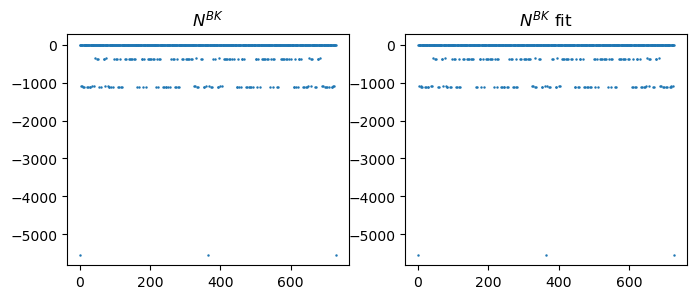

In [20]:
fig, ax = plt.subplots(1, 2, figsize=(8,3))
ax[0].plot(NBK_avg.flatten(), '.', ms=1.5)
ax[0].set_title(r"$N^{BK}$")
ax[1].plot(isotropic3(moduli_inf).flatten(), '.', ms=1.5)
ax[1].set_title(r"$N^{BK}$ fit")
plt.show()

In [7]:
del born_nl_raw, press_kin_raw, press_pot_raw, press_raw, stress_kin
gc.collect()

5365

In [7]:
del press_data, press_pot_data, born_data, born_nl_data, born_voigt, born_nl_voigt
gc.collect()

1034

## Nonlinear moduli

### Individual

In [8]:
stress_d.shape

(50000001, 3, 3)

In [9]:
def CBK_stress_term(CBK, stress, born_len, V, T, ind=(0,0,0,0,0,0), last_idx=None):
    i,j,k,l,m,n = ind
    last_idx = born_len if not last_idx else min(last_idx, born_len)
    stress_ = stress[:last_idx] - stress[:last_idx].mean(0)
    return - V/(2*T) * (CBK[:last_idx,i,j,k,l] * stress_[:last_idx,m,n] + 
                        CBK[:last_idx,i,j,m,n] * stress_[:last_idx,k,l] +
                        CBK[:last_idx,k,l,m,n] * stress_[:last_idx,i,j])

def stress3_term(stress, V, T, ind=(0,0,0,0,0,0), last_idx=None):
    i,j,k,l,m,n = ind
    stress_ = stress[:last_idx] - stress[:last_idx].mean(0)
    return V**2 / (2*T**2) * (stress_[:,i,j] * stress_[:,k,l] * stress_[:,m,n])

In [10]:
#ind = 0, 1, 2, 1, 0, 2
#i, j, k, l, m, n = 0,2,0,2,0,2
ind = 0,0,0,0,0,0
#ind = 1,1,1,1,1,1
#ind = 2,2,2,2,2,2
V = thermo_data.vol.mean()
T = thermo_data.temp.mean()

CBK_stress = CBK_stress_term(CBK, stress, born_len, V, T, ind).mean(0)
stress3 = stress3_term(stress, V, T, ind).mean(0)
modulus_stat = NBK_avg[*ind] + CBK_stress + stress3

print(f'NBK:   {NBK_avg[*ind]:7.1f}')
print(f'Corr2: {CBK_stress:7.1f}')
print(f'Corr3: {stress3:7.1f}\n')
print(f'NBK+corr2: {NBK_avg[*ind]+CBK_stress:7.1f}')
print(f'pressure:  {press_avg:7.1f}')

NBK:   -5527.4
Corr2:  3417.4
Corr3: -1075.9

NBK+corr2: -2110.0
pressure:     35.0


In [11]:
def convergence(func, args, pnum=10, log=True, start=10, stop=100):
    if log:
        last_ind = np.array(np.logspace(np.log10(start), np.log10(stop), num=pnum), dtype=int)
    else:
        last_ind = np.array(np.linspace(int(start), int(stop), num=pnum), dtype=int)
    res = np.zeros_like(last_ind, dtype=float)
    for ind, li in enumerate(last_ind):
        #res[ind] = (arr[:li]).mean()
        res[ind] = func(*args, last_idx=li).mean()
    return res, last_ind    

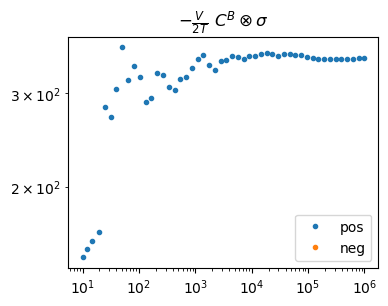

In [111]:
#CBKsigma, last_ind = convergence(CBK_stress_term(CBK, stress_d, born_len, V, T, ind), pnum=100)
CBKsigma, last_ind = convergence(CBK_stress_term, [CBK, stress, born_len, V, T, ind], 
                                 pnum=50, stop=born_len)
mask = CBKsigma > 0
plt.figure(figsize=(4,3))
plt.plot(last_ind[mask], CBKsigma[mask], '.', label='pos')
plt.plot(last_ind[np.logical_not(mask)], -CBKsigma[np.logical_not(mask)], '.', label='neg')
#plt.plot(last_ind, last_ind**(-1/2) * 5e4, '--', label=r'$N^{0.5}$')
plt.legend()
plt.title(r'$-\frac{V}{2T}\ C^B \otimes \sigma$')
plt.xscale('log')
plt.yscale('log')

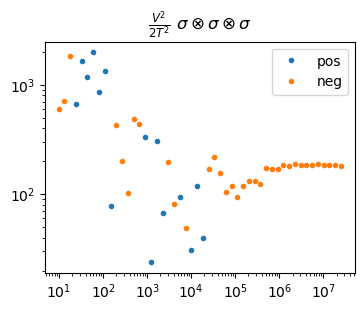

In [112]:
sigma3mean, last_ind = convergence(stress3_term, [stress, V, T, ind], 
                                   pnum=50, stop=len(stress))
mask = sigma3mean > 0
plt.figure(figsize=(4,3))
plt.plot(last_ind[mask], sigma3mean[mask], '.', label='pos')
plt.plot(last_ind[np.logical_not(mask)], -sigma3mean[np.logical_not(mask)], '.', label='neg')
#plt.plot(last_ind, last_ind**(-1/2) * 5e4, '--', label=r'$N^{0.5}$')
plt.legend()
plt.title(r'$\frac{V^2}{2T^2}\ \sigma \otimes \sigma \otimes \sigma$')
plt.xscale('log')
plt.yscale('log')

Text(0.5, 1.0, '$\\frac{V^2}{2T^2}\\ \\sigma \\otimes \\sigma \\otimes \\sigma$')

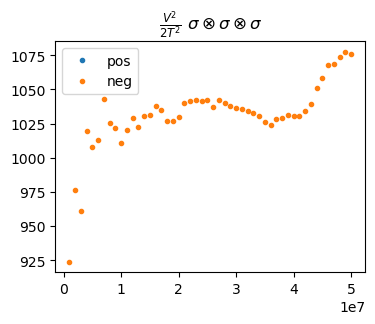

In [13]:
sigma3mean, last_ind = convergence(stress3_term, [stress, V, T, ind], 
                                   pnum=50, log=False, start=1e6, stop=len(stress))
mask = sigma3mean > 0
plt.figure(figsize=(4,3))
plt.plot(last_ind[mask], sigma3mean[mask], '.', label='pos')
plt.plot(last_ind[np.logical_not(mask)], -sigma3mean[np.logical_not(mask)], '.', label='neg')
plt.legend()
plt.title(r'$\frac{V^2}{2T^2}\ \sigma \otimes \sigma \otimes \sigma$')
#plt.xscale('log')
#plt.yscale('log')

In [12]:
modulus_stat

np.float64(-3185.881074978256)

### All of them

In [14]:
V = thermo_data.vol.mean()
T = thermo_data.temp.mean()
stress_d_born = stress[:born_len] - stress[:born_len].mean(0)
N_qs_corr2 = - V/(2*T) * (np.einsum('pijkl,pmn->ijklmn', CBK, stress_d_born) + 
                          np.einsum('pijmn,pkl->ijklmn', CBK, stress_d_born) + 
                          np.einsum('pklmn,pij->ijklmn', CBK, stress_d_born) ) / born_len
N_qs_corr3 = V**2 / (2*T**2) * np.einsum('pij,pkl,pmn->ijklmn', 
                                         stress_d, stress_d, stress_d) / len(stress_d)
N_qs = NBK_avg + N_qs_corr2 + N_qs_corr3

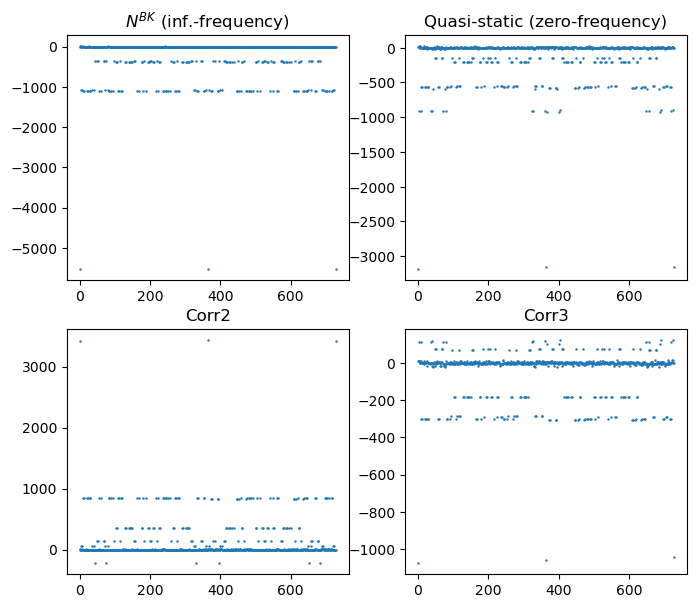

In [15]:
fig, ax = plt.subplots(2,2, figsize=(8,7))
ax[0,0].set_title(r'$N^{BK}$ (inf.-frequency)')
ax[0,0].plot(NBK_avg.flatten(), '.', ms=1.5)
ax[0,1].set_title('Quasi-static (zero-frequency)')
ax[0,1].plot(N_qs.flatten(), '.', ms=1.5)

ax[1,0].set_title('Corr2')
ax[1,0].plot(N_qs_corr2.flatten(), '.', ms=1.5)
ax[1,1].set_title('Corr3')
ax[1,1].plot(N_qs_corr3.flatten(), '.', ms=1.5)

In [16]:
moduli0, re = fit_isotropic3(N_qs)
for key, value in moduli0.items():
    print(f"{key}: {value:.1f}")
print(f"rel.err.: {re:.2e}")

A: -604.7
B: -304.8
C: -1643.7
rel.err.: 2.00e-02


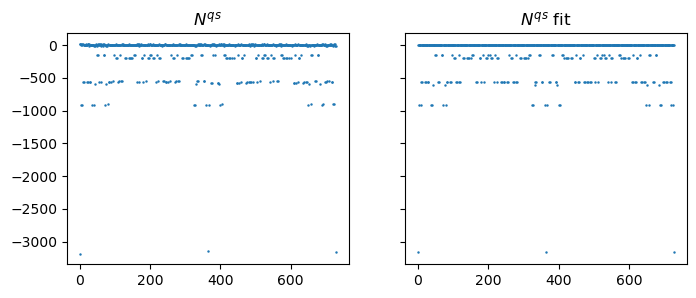

In [17]:
fig, ax = plt.subplots(1, 2, figsize=(8,3), sharey=True)
ax[0].plot(N_qs.flatten(), '.', ms=1.5)
ax[0].set_title(r"$N^{qs}$")
ax[1].plot(isotropic3(moduli0).flatten(), '.', ms=1.5)
ax[1].set_title(r"$N^{qs}$ fit")
plt.show()

In [42]:
landau2murn(moduli0)

{'l': np.float64(-893.1154577057343),
 'm': np.float64(529.6051794616951),
 'n': np.float64(-1643.6650967262703)}

In [18]:
moduli0['C'] / 8

np.float64(-205.466877461163)

In [44]:
8*press_avg

np.float64(279.8057833114074)

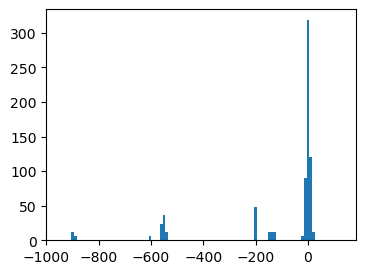

In [124]:
plt.figure(figsize=(4,3))
plt.hist(N_qs.flatten(), bins=300)
plt.xlim(-1000, None)
plt.show()

## Stress distribution

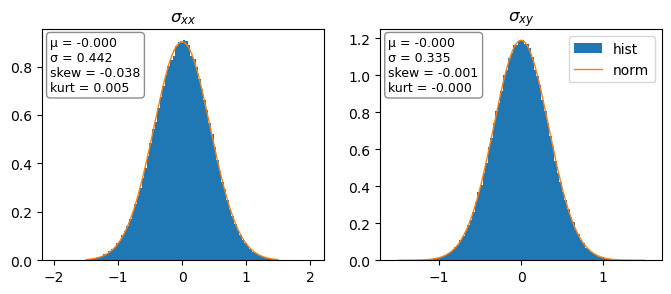

In [27]:
fig, ax = plt.subplots(1,2, figsize=(8,3))
x = np.linspace(-1.5, 1.5, num=200)

arr = stress_d[:,0,0]
ax[0].set_title(r"$\sigma_{xx}$")
ax[0].hist(arr, density=True, bins=100)
ax[0].plot(x, sp.stats.norm.pdf(x, arr.mean(), arr.std()), lw=1)
stats_text = f'μ = {arr.mean():.3f}\nσ = {arr.std():.3f}\n\
skew = {sp.stats.skew(arr):.3f}\nkurt = {sp.stats.kurtosis(arr):.3f}'
ax[0].text(0.03, 0.97, stats_text, transform=ax[0].transAxes,
           verticalalignment='top', horizontalalignment='left',
           bbox=dict(boxstyle='round', facecolor='white', alpha=0.9, edgecolor='gray'),
           fontsize=9)

arr = stress_d[:,0,1]
ax[1].set_title(r"$\sigma_{xy}$")
ax[1].hist(arr, density=True, bins=100, label='hist')
ax[1].plot(x, sp.stats.norm.pdf(x, arr.mean(), arr.std()), lw=1, label='norm')
ax[1].legend()
stats_text = f'μ = {arr.mean():.3f}\nσ = {arr.std():.3f}\n\
skew = {sp.stats.skew(arr):.3f}\nkurt = {sp.stats.kurtosis(arr):.3f}'
ax[1].text(0.03, 0.97, stats_text, transform=ax[1].transAxes,
           verticalalignment='top', horizontalalignment='left',
           bbox=dict(boxstyle='round', facecolor='white', alpha=0.9, edgecolor='gray'),
           fontsize=9)

#fig.savefig("sigma_dist.png")
plt.show()

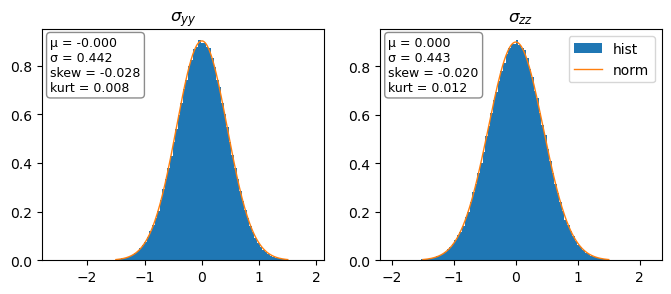

In [50]:
fig, ax = plt.subplots(1,2, figsize=(8,3))
x = np.linspace(-1.5, 1.5, num=200)

arr = stress_d[:,1,1]
ax[0].set_title(r"$\sigma_{yy}$")
ax[0].hist(arr, density=True, bins=100)
ax[0].plot(x, sp.stats.norm.pdf(x, arr.mean(), arr.std()), lw=1)
stats_text = f'μ = {arr.mean():.3f}\nσ = {arr.std():.3f}\n\
skew = {sp.stats.skew(arr):.3f}\nkurt = {sp.stats.kurtosis(arr):.3f}'
ax[0].text(0.03, 0.97, stats_text, transform=ax[0].transAxes,
           verticalalignment='top', horizontalalignment='left',
           bbox=dict(boxstyle='round', facecolor='white', alpha=0.9, edgecolor='gray'),
           fontsize=9)

arr = stress_d[:,2,2]
ax[1].set_title(r"$\sigma_{zz}$")
ax[1].hist(arr, density=True, bins=100, label='hist')
ax[1].plot(x, sp.stats.norm.pdf(x, arr.mean(), arr.std()), lw=1, label='norm')
ax[1].legend()
stats_text = f'μ = {arr.mean():.3f}\nσ = {arr.std():.3f}\n\
skew = {sp.stats.skew(arr):.3f}\nkurt = {sp.stats.kurtosis(arr):.3f}'
ax[1].text(0.03, 0.97, stats_text, transform=ax[1].transAxes,
           verticalalignment='top', horizontalalignment='left',
           bbox=dict(boxstyle='round', facecolor='white', alpha=0.9, edgecolor='gray'),
           fontsize=9)

#fig.savefig("sigma_dist.png")
plt.show()

In [28]:
sp.stats.skewtest(stress_d[:,0,1])

SkewtestResult(statistic=np.float64(-0.23059548487766102), pvalue=np.float64(0.8176290756355113))

In [29]:
sp.stats.skewtest(stress_d[:,0,0])

SkewtestResult(statistic=np.float64(-9.829043929355755), pvalue=np.float64(8.4416353431131e-23))

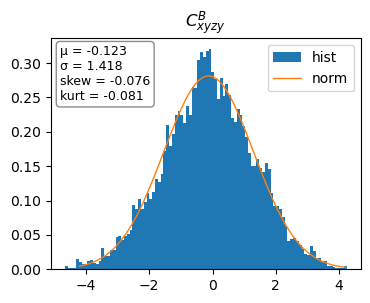

In [145]:
fig, ax = plt.subplots(1,1, figsize=(4,3))
x = np.linspace(-4.2, 4.2, num=200)

arr = CB[:,i,j,k,l]
ax.set_title(r"$C^B_{xyzy}$")
ax.hist(arr, density=True, bins=100, label='hist')
ax.plot(x, sp.stats.norm.pdf(x, arr.mean(), arr.std()), lw=1, label='norm')
ax.legend()
stats_text = f'μ = {arr.mean():.3f}\nσ = {arr.std():.3f}\n\
skew = {sp.stats.skew(arr):.3f}\nkurt = {sp.stats.kurtosis(arr):.3f}'
ax.text(0.03, 0.97, stats_text, transform=ax.transAxes,
           verticalalignment='top', horizontalalignment='left',
           bbox=dict(boxstyle='round', facecolor='white', alpha=0.9, edgecolor='gray'),
           fontsize=9)
plt.show()

In [99]:
sp.stats.skewtest(CB[:,i,j,k,l])

SkewtestResult(statistic=np.float64(-9.762265244806203), pvalue=np.float64(1.634625744676164e-22))

In [100]:
arr = V**2 / (2*T**2) * (stress_d[:,i,j] * stress_d[:,k,l] * stress_d[:,m,n])
sp.stats.skewtest(arr)

SkewtestResult(statistic=np.float64(8.118836599860872), pvalue=np.float64(4.706737083952397e-16))

In [146]:
arr = V/(2*T) * (CBK[:,i,j,k,l] * stress_d[:,m,n] + 
                 CBK[:,i,j,m,n] * stress_d[:,k,l] +
                 CBK[:,k,l,m,n] * stress_d[:,i,j])
sp.stats.skewtest(arr)

SkewtestResult(statistic=np.float64(-124.76961270563021), pvalue=np.float64(0.0))

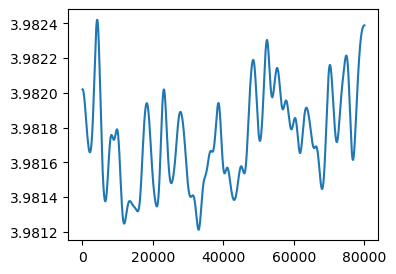

In [40]:
plt.figure(figsize=(4,3))
plt.plot(thermo_data.time, sp.ndimage.gaussian_filter(thermo_data.temp, 4000))

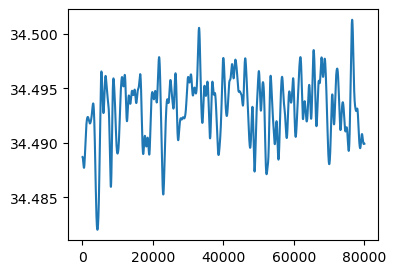

In [35]:
plt.figure(figsize=(4,3))
plt.plot(thermo_data.time, sp.ndimage.gaussian_filter((press_data.xx+press_data.yy+press_data.zz)/3, 1500))

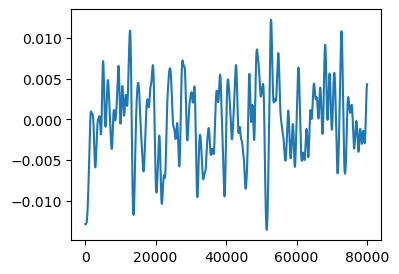

In [36]:
plt.figure(figsize=(4,3))
plt.plot(thermo_data.time, sp.ndimage.gaussian_filter(press_data.xy, 1500))